# Satellite Land Cover Classification
## 01 - Exploratory Data Analysis

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 12

In [2]:
DATASET_PATH = Path("../data/raw/eurosat_subset")

CLASSES = [
    "Forest",
    "River",
    "Residential"
]

print(DATASET_PATH)
print(CLASSES)

../data/raw/eurosat_subset
['Forest', 'River', 'Residential']


In [3]:
for land_class in CLASSES:

    folder = DATASET_PATH / land_class

    images = list(folder.glob("*.jpg"))

    print(f"{land_class:<15} {len(images)} images")

Forest          3000 images
River           2500 images
Residential     3000 images


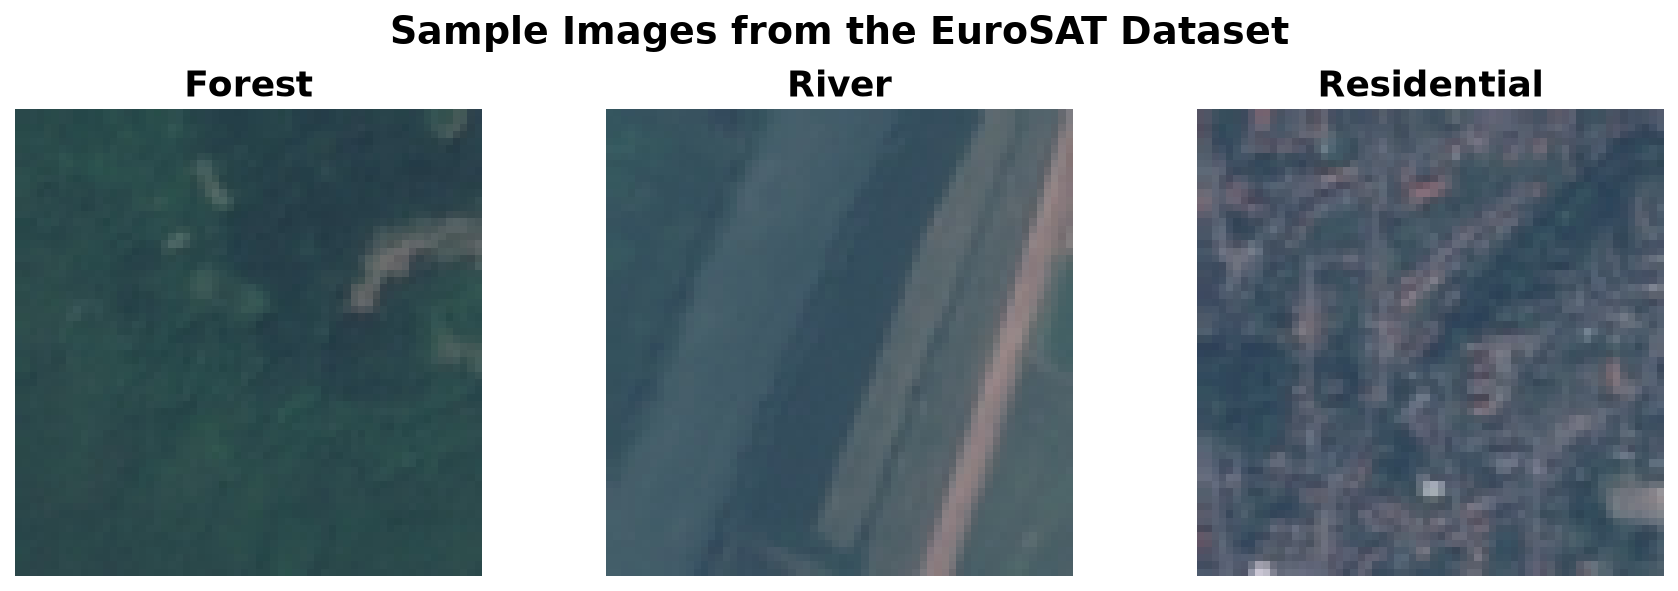

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, land_class in zip(axes, CLASSES):

    folder = DATASET_PATH / land_class

    image_path = random.choice(list(folder.glob("*.jpg")))

    image = Image.open(image_path)

    ax.imshow(image)

    ax.set_title(land_class,
                 fontweight="bold")

    ax.axis("off")

plt.suptitle(
    "Sample Images from the EuroSAT Dataset",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../images/sample_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

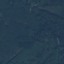

In [5]:
forest_folder = DATASET_PATH / "Forest"

sample_image = Image.open(sorted(forest_folder.glob("*.jpg"))[0])

sample_image

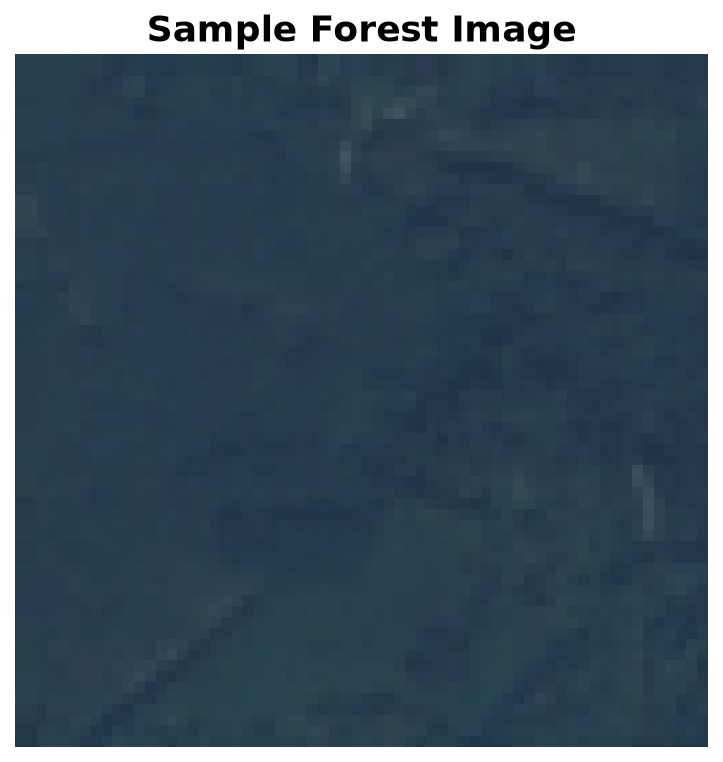

In [6]:
plt.imshow(sample_image)

plt.title(
    "Sample Forest Image",
    fontweight="bold"
)

plt.axis("off")

plt.show()

In [7]:
image_array = np.array(sample_image)

print(type(image_array))
print()

print(image_array.shape)
print()

print(image_array.dtype)

<class 'numpy.ndarray'>

(64, 64, 3)

uint8


In [8]:
print("Top-left pixel")

print(image_array[0,0])

Top-left pixel
[40 63 79]


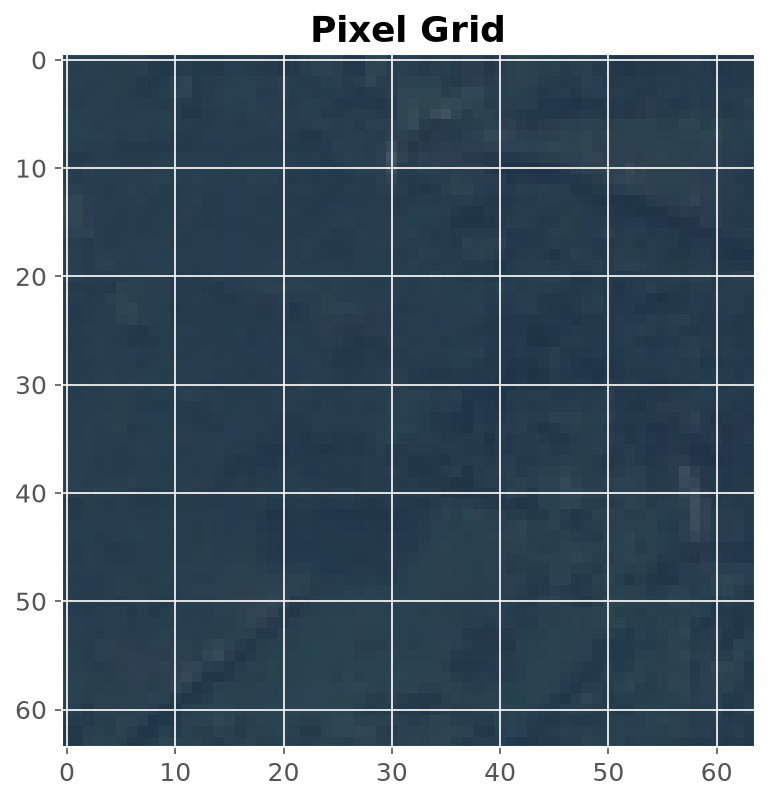

In [9]:
plt.figure(figsize=(6,6))

plt.imshow(sample_image)

plt.grid(True)

plt.title(
    "Pixel Grid",
    fontweight="bold"
)

plt.show()

In [10]:
red = image_array[:,:,0]

green = image_array[:,:,1]

blue = image_array[:,:,2]

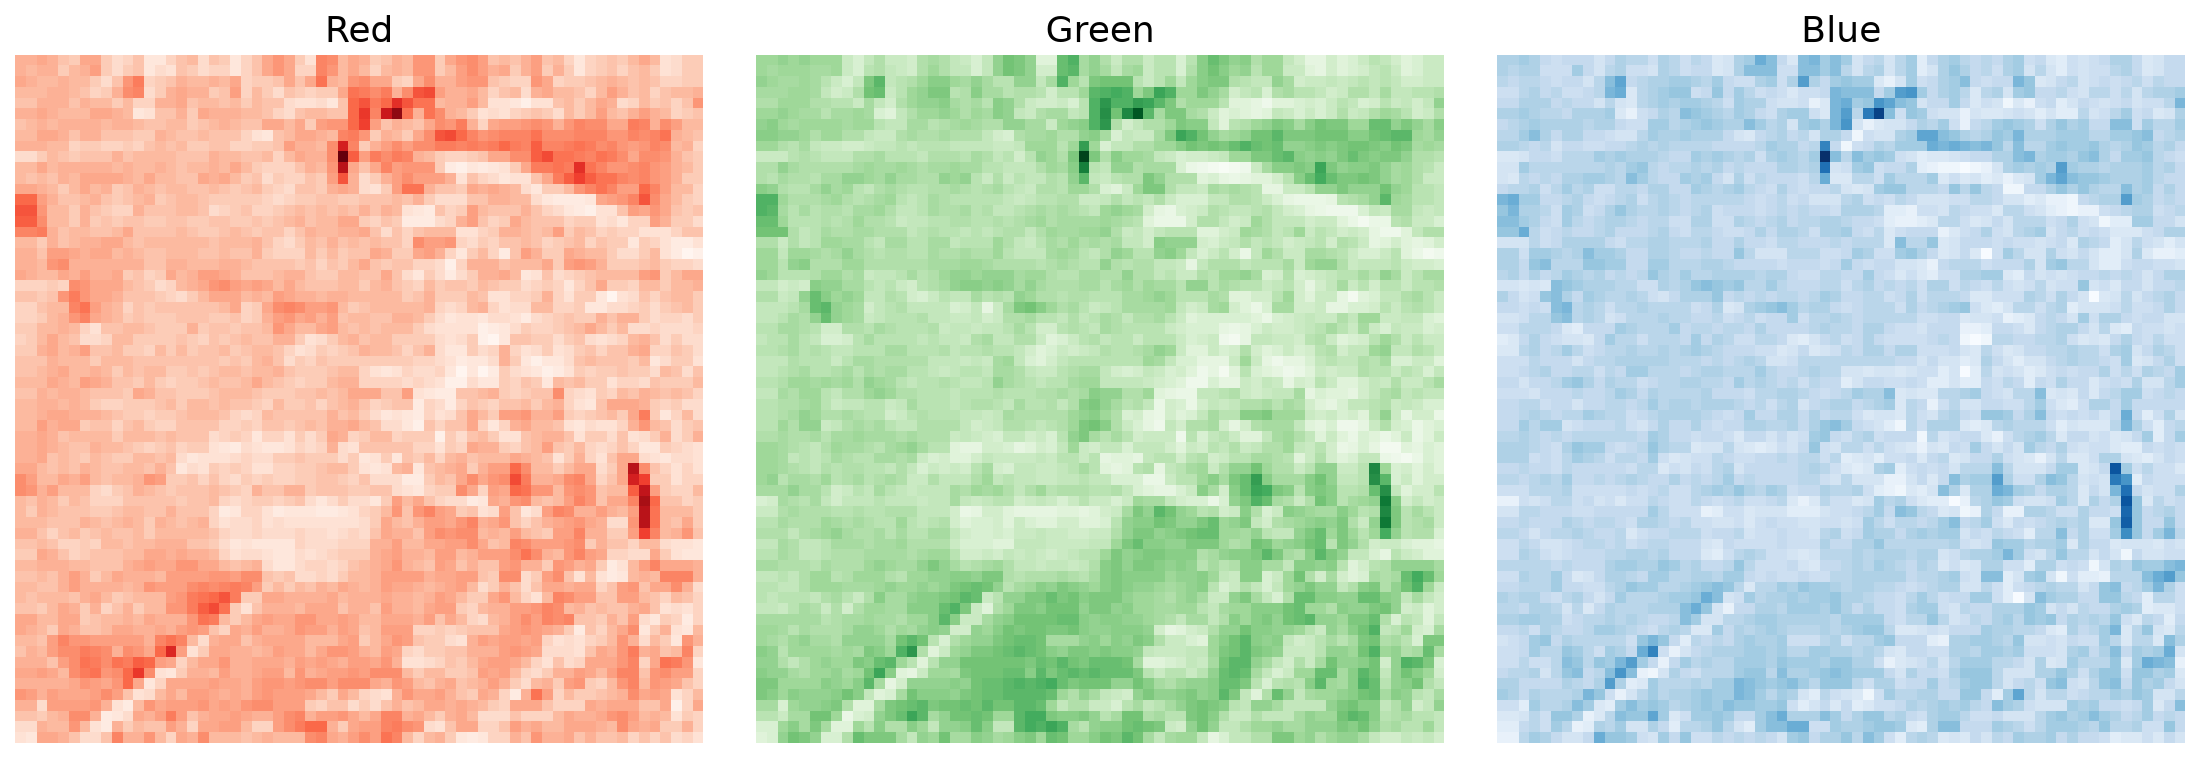

In [11]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].imshow(red, cmap="Reds")
axes[0].set_title("Red")
axes[0].axis("off")

axes[1].imshow(green, cmap="Greens")
axes[1].set_title("Green")
axes[1].axis("off")

axes[2].imshow(blue, cmap="Blues")
axes[2].set_title("Blue")
axes[2].axis("off")

plt.tight_layout()

plt.show()

In [12]:
sizes = []

for land_class in CLASSES:

    folder = DATASET_PATH / land_class

    for image_path in folder.glob("*.jpg"):

        image = Image.open(image_path)

        sizes.append(image.size)

unique_sizes = set(sizes)

print(unique_sizes)

{(64, 64)}


In [13]:
print("Average Red :", red.mean())

print("Average Green :", green.mean())

print("Average Blue :", blue.mean())

Average Red : 38.9072265625
Average Green : 61.089111328125
Average Blue : 77.587158203125


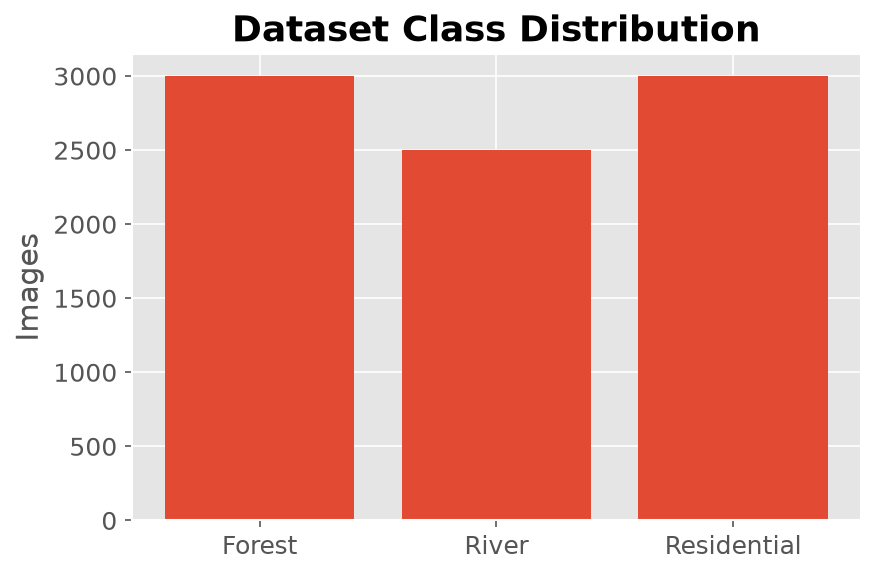

In [14]:
counts = []

for land_class in CLASSES:

    folder = DATASET_PATH / land_class

    counts.append(len(list(folder.glob("*.jpg"))))

plt.figure(figsize=(6,4))

plt.bar(CLASSES, counts)

plt.title(
    "Dataset Class Distribution",
    fontweight="bold"
)

plt.ylabel("Images")

plt.tight_layout()

plt.savefig(
    "../images/class_distribution.png",
    dpi=300
)

plt.show()

## Key Takeaways

- Images are stored as NumPy arrays.
- Every image has dimensions of 64 × 64 pixels with three RGB channels.
- Pixel values range from 0 to 255.
- Each satellite image can therefore be represented numerically, allowing machine learning models to learn patterns from pixel statistics.
- The dataset contains three land cover classes: Forest, River, and Residential.
- All images share identical dimensions, simplifying downstream preprocessing.